# Avance 4 – Modelos Alternativos
## Proyecto Integrador – Equipo 22

Integrantes:
*   María Virginia Mendizábal Miranda - A01796588
*   Gianmel Joannelly Hernandez Tosta - A01795919
*   Sofía Ordaz López - A01173717

**Proyecto:** Análisis de biomarcadores lipidómicos y metabolómicos mediante modelos de *machine learning* interpretativo para clasificación multiclase de cáncer colorrectal.

# Objetivo
El objetivo de esta fase es evaluar múltiples algoritmos de clasificación para determinar cuáles presentan el mejor desempeño en la clasificación multiclase de pacientes CTRL, AA y CRC utilizando biomarcadores lipidómicos y metabolómicos.

Siguiendo la metodología CRISP-ML(Q), se compararán diferentes modelos utilizando métricas consistentes con el baseline desarrollado en el Avance 3. Posteriormente se realizará ajuste de hiperparámetros sobre los modelos con mejor desempeño para seleccionar un modelo final.

## Librerías

In [1]:
# ============================================================
# Librerías
# ============================================================

import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

## Carga del dataset

In [2]:
# 2. Carga del dataset, el mismo dataset utilizado en Avance 3

# ============================================================
#  Montar Google Drive y definir ruta del dataset
# ============================================================
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

DATA_PATH = '/content/drive/MyDrive/Proyecto Integrador/Entrega 31 Mayo/'
file_path = DATA_PATH + 'avance2_X_intersect.csv'

print('Ruta del archivo:', file_path)

Mounted at /content/drive
Ruta del archivo: /content/drive/MyDrive/Proyecto Integrador/Entrega 31 Mayo/avance2_X_intersect.csv


In [3]:
# ============================================================
# Cargar dataset final
# ============================================================

data = pd.read_csv(
    file_path,
    encoding='latin1'
)

print("Dimensiones:", data.shape)

data.head()

Dimensiones: (211, 16)


,CE(20:5),GlcCer(d18:1/24:0),PC(36:5),PC(O-16:0/16:0),PC(O-16:0/18:2),PC(O-34:1),SM(33:1),SM(42:3),SM(d18:1/22:0),SM(d18:1/23:0),SM(d18:1/24:1) + SM(d18:2/24:0),TG(51:4),fit_ug_g,age,gender_Male,fob_YES
0,0.883784,1.430422,0.155875,3.789349,2.012357,2.424742,2.487655,2.409375,2.316616,2.324193,2.588410,0.097011,-1.025573,0.114724,1,0
1,0.010448,0.253402,-0.203939,-0.419051,1.994415,0.782273,1.306299,-0.448485,0.272724,0.008021,0.179774,0.424891,1.251480,0.575455,0,1
2,0.306966,0.403584,-1.587194,0.463327,-0.391872,0.193911,0.493873,0.029096,-0.675153,0.496688,0.144890,-1.950313,1.251480,-0.950829,1,1
3,1.810424,-0.136626,1.223409,0.366599,1.001063,1.044246,0.149334,0.263777,-0.025028,-0.045723,0.488084,-0.178296,1.251480,1.080670,1,1
4,-0.568229,0.253402,-0.203939,-0.672886,-0.505652,-1.011195,-1.605365,-0.300000,-1.093585,-0.265947,-0.145450,0.035715,-1.025573,-0.222776,0,0


In [4]:
# ============================================================
# Información general del dataset
# ============================================================

print("Número de muestras:", data.shape[0])

print("Número total de variables predictoras:", data.shape[1])

print("\nVariables clínicas:")
print(['age', 'fit_ug_g'])

print("\nVariables categóricas:")
print(['gender_Male', 'fob_YES'])

print("\nNúmero de biomarcadores lipidómicos/metabolómicos:")
print(12)

Número de muestras: 211
Número total de variables predictoras: 16

Variables clínicas:
['age', 'fit_ug_g']

Variables categóricas:
['gender_Male', 'fob_YES']

Número de biomarcadores lipidómicos/metabolómicos:
12


## Matriz predictora y variable objetivo

In [5]:
# ============================================================
# Definir matriz predictora y variable objetivo
# ============================================================

X = data.copy()

y = pd.read_csv(
    DATA_PATH + 'avance2_y.csv',
    encoding='latin1'
).squeeze()

print("Dimensiones X:", X.shape)
print("Dimensiones y:", y.shape)
print("\nDistribución de clases:")
print(y.value_counts())

Dimensiones X: (211, 16)
Dimensiones y: (211,)

Distribución de clases:
group
CTRL    78
CRC     75
AA      58
Name: count, dtype: int64


## Modelos alternativos

Se evaluaron seis modelos individuales de clasificación supervisada, evitando modelos ensamble para cumplir con las instrucciones de la actividad.

Los modelos seleccionados fueron:

1. Logistic Regression
2. Decision Tree
3. Support Vector Machine
4. K-Nearest Neighbors
5. Gaussian Naive Bayes
6. Linear Discriminant Analysis

Estos modelos representan enfoques variados: modelos lineales, modelos basados en reglas, modelos basados en distancia, modelos probabilísticos y métodos de separación de clases.

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=5000,
        multi_class='multinomial',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'SVM': SVC(
        random_state=42
    ),

    'KNN': KNeighborsClassifier(),

    'Gaussian NB': GaussianNB(),

    'LDA': LinearDiscriminantAnalysis()
}

## Comparativa de modelos

In [7]:
# ============================================================
# Evaluación comparativa de modelos
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    start_time = time.time()

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=[
            'accuracy',
            'precision_macro',
            'recall_macro',
            'f1_macro'
        ],
        return_train_score=True
    )

    elapsed_time = time.time() - start_time

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision Macro': scores['test_precision_macro'].mean(),
        'Recall Macro': scores['test_recall_macro'].mean(),
        'F1 Macro': scores['test_f1_macro'].mean(),
        'Train F1 Macro': scores['train_f1_macro'].mean(),
        'Fit Time Mean': scores['fit_time'].mean(),
        'Total Time': elapsed_time
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1 Macro',
    ascending=False
).reset_index(drop=True)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Train F1 Macro,Fit Time Mean,Total Time
0,Decision Tree,0.663677,0.666399,0.648990,0.648773,1.000000,0.016377,0.446819
1,KNN,0.635105,0.636868,0.627399,0.625262,0.737811,0.008193,0.360440
2,LDA,0.639978,0.620873,0.615202,0.607642,0.692763,0.005234,0.202361
3,SVM,0.620819,0.612716,0.603535,0.596583,0.824051,0.009684,0.294324
4,Gaussian NB,0.601993,0.606887,0.594545,0.592186,0.662909,0.005000,0.182898
5,Logistic Regression,0.625581,0.590447,0.599747,0.587835,0.702655,0.047645,0.528708


La comparación se ordenó utilizando F1 Macro como métrica principal, ya que fue la métrica seleccionada en el Avance 3 debido al carácter multiclase del problema y a las ligeras diferencias en la distribución de clases. Además, se consideraron Accuracy, Precision Macro, Recall Macro y tiempo de entrenamiento para evaluar el equilibrio entre desempeño y costo computacional.

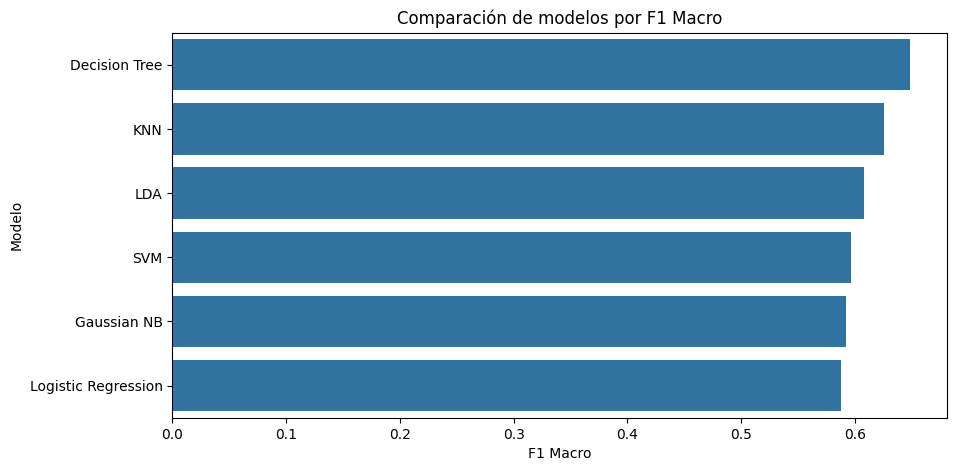

In [8]:
# ============================================================
# Visualización comparativa
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x='F1 Macro',
    y='Model'
)

plt.title('Comparación de modelos por F1 Macro')
plt.xlabel('F1 Macro')
plt.ylabel('Modelo')

plt.show()

## Selección de los dos mejores modelos

In [9]:
# ============================================================
# Selección de los dos mejores modelos
# ============================================================

top_2_models = results_df.head(2)

top_2_models

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Train F1 Macro,Fit Time Mean,Total Time
0,Decision Tree,0.663677,0.666399,0.648990,0.648773,1.000000,0.016377,0.446819
1,KNN,0.635105,0.636868,0.627399,0.625262,0.737811,0.008193,0.360440


## Selección de modelos para ajuste fino

Los dos modelos con mejor desempeño según F1 Macro fueron seleccionados para ajuste de hiperparámetros. Esta selección permite enfocar el proceso de optimización en los modelos más prometedores, manteniendo consistencia con la métrica principal definida desde el baseline.

## Ajuste fino de hiperparámetros

In [10]:
# ============================================================
# Espacios de búsqueda por modelo
# ============================================================

param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs'],
        'penalty': ['l2']
    },

    'Decision Tree': {
        'max_depth': [2, 3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'criterion': ['gini', 'entropy']
    },

    'SVM': {
        'C': [0.01, 0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },

    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },

    'Gaussian NB': {
        'var_smoothing': np.logspace(-12, -6, 7)
    },

    'LDA': {
        'solver': ['svd', 'lsqr'],
        'shrinkage': [None, 'auto']
    }
}

In [11]:
# ============================================================
# Ajustar los dos mejores modelos
# ============================================================

best_model_names = top_2_models['Model'].tolist()

tuned_results = []
best_estimators = {}

for model_name in best_model_names:

    print(f"Ajustando modelo: {model_name}")

    grid_search = GridSearchCV(
        estimator=models[model_name],
        param_grid=param_grids[model_name],
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1
    )

    start_time = time.time()

    grid_search.fit(X, y)

    elapsed_time = time.time() - start_time

    best_estimators[model_name] = grid_search.best_estimator_

    tuned_results.append({
        'Model': model_name,
        'Best F1 Macro': grid_search.best_score_,
        'Best Params': grid_search.best_params_,
        'Tuning Time': elapsed_time
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

Ajustando modelo: Decision Tree
Ajustando modelo: KNN


,Model,Best F1 Macro,Best Params,Tuning Time
0,Decision Tree,0.698288,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",27.009886
1,KNN,0.723407,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei...",1.260743


## Resultados del ajuste de hiperparámetros

El proceso de ajuste fino permitió mejorar el desempeño de ambos modelos seleccionados mediante la exploración sistemática de diferentes configuraciones de hiperparámetros utilizando GridSearchCV.

El Árbol de Decisión alcanzó un F1 Macro de 0.698 con una profundidad máxima de 5 niveles y el criterio de partición basado en entropía. Esto sugiere que una estructura moderadamente profunda permite capturar patrones relevantes sin incrementar excesivamente la complejidad del modelo.

Por su parte, K-Nearest Neighbors obtuvo el mejor desempeño global con un F1 Macro de 0.723 utilizando 7 vecinos, distancia Manhattan y ponderación por distancia. Esta configuración indica que la similitud local entre pacientes resulta altamente informativa para la clasificación de los grupos clínicos.

La mejora observada fue de 0.050 puntos de F1 Macro para Decision Tree y de 0.098 puntos para KNN, evidenciando que el ajuste de hiperparámetros tuvo un impacto positivo especialmente en KNN.

Adicionalmente, KNN requirió un tiempo de ajuste considerablemente menor (1.26 segundos) en comparación con Decision Tree (27.01 segundos), obteniendo simultáneamente el mejor desempeño predictivo. Estos resultados respaldan la selección de KNN como candidato principal para el modelo individual final.

## Comparación antes vs. después

In [12]:
# ============================================================
# Comparación antes vs después del ajuste
# ============================================================

comparison_rows = []

for model_name in best_model_names:

    before_f1 = results_df.loc[
        results_df['Model'] == model_name,
        'F1 Macro'
    ].values[0]

    after_f1 = tuned_results_df.loc[
        tuned_results_df['Model'] == model_name,
        'Best F1 Macro'
    ].values[0]

    comparison_rows.append({
        'Model': model_name,
        'F1 Before Tuning': before_f1,
        'F1 After Tuning': after_f1,
        'Improvement': after_f1 - before_f1
    })

tuning_comparison = pd.DataFrame(comparison_rows)

tuning_comparison

,Model,F1 Before Tuning,F1 After Tuning,Improvement
0,Decision Tree,0.648773,0.698288,0.049516
1,KNN,0.625262,0.723407,0.098146


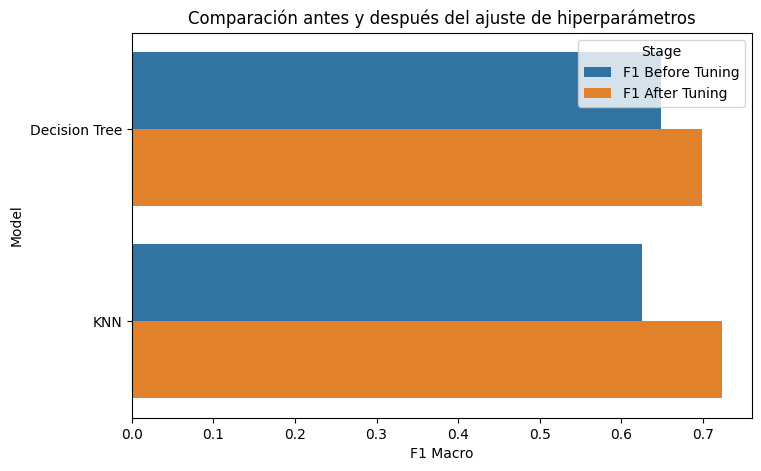

In [13]:
plt.figure(figsize=(8, 5))

tuning_comparison_melted = tuning_comparison.melt(
    id_vars='Model',
    value_vars=['F1 Before Tuning', 'F1 After Tuning'],
    var_name='Stage',
    value_name='F1 Macro'
)

sns.barplot(
    data=tuning_comparison_melted,
    x='F1 Macro',
    y='Model',
    hue='Stage'
)

plt.title('Comparación antes y después del ajuste de hiperparámetros')

plt.show()

## Comparación antes vs. después del ajuste de hiperparámetros

El ajuste fino de hiperparámetros produjo mejoras en ambos modelos seleccionados para optimización.

En el caso de **Decision Tree**, el valor de F1 Macro aumentó de **0.649** a **0.698**, lo que representa una mejora absoluta de **0.050 puntos**. Esto indica que una configuración más adecuada de profundidad del árbol y criterios de partición permitió mejorar la capacidad de generalización del modelo.

Por su parte, **K-Nearest Neighbors (KNN)** mostró una mejora más significativa, incrementando su F1 Macro de **0.625** a **0.723**, equivalente a una ganancia de **0.098 puntos**. Este resultado sugiere que la selección óptima del número de vecinos y de la métrica de distancia tuvo un impacto importante en la capacidad del modelo para discriminar entre las clases CTRL, AA y CRC.

Al comparar ambos modelos después del ajuste, **KNN obtuvo el mejor desempeño global**, alcanzando el valor más alto de F1 Macro y mostrando además la mayor mejora relativa respecto a su configuración inicial.

Estos resultados evidencian la importancia del ajuste de hiperparámetros dentro del proceso de modelado, ya que configuraciones adecuadas pueden incrementar significativamente el desempeño predictivo sin necesidad de recurrir a modelos más complejos.

In [14]:
# ============================================================
# Resumen final de modelos candidatos
# ============================================================

final_summary = pd.DataFrame({
    'Modelo': ['Decision Tree', 'KNN'],
    'F1 Inicial': [0.648773, 0.625262],
    'F1 Ajustado': [0.698288, 0.723407]
})

final_summary = final_summary.sort_values(
    by='F1 Ajustado',
    ascending=False
)

final_summary

,Modelo,F1 Inicial,F1 Ajustado
1,KNN,0.625262,0.723407
0,Decision Tree,0.648773,0.698288


## Resumen de selección del modelo final

Después del proceso de ajuste de hiperparámetros, los dos modelos con mejor desempeño fueron Decision Tree y K-Nearest Neighbors (KNN).

La tabla anterior muestra que ambos modelos mejoraron su desempeño respecto a sus configuraciones iniciales. Sin embargo, KNN alcanzó el mayor valor de F1 Macro ajustado (0.723), superando tanto al árbol de decisión ajustado (0.698) como al baseline desarrollado en el Avance 3 (0.587).

Estos resultados permitieron seleccionar KNN como candidato principal para la evaluación final detallada y el análisis de desempeño por clase.

## Modelo individual final

In [15]:
# ============================================================
# Selección del modelo individual final
# ============================================================

final_model_name = tuned_results_df.sort_values(
    by='Best F1 Macro',
    ascending=False
).iloc[0]['Model']

final_model = best_estimators[final_model_name]

print("Modelo final seleccionado:", final_model_name)
print("Configuración final:")
print(final_model)

Modelo final seleccionado: KNN
Configuración final:
KNeighborsClassifier(metric='manhattan', n_neighbors=7, weights='distance')


In [16]:
# ============================================================
# Evaluación final con validación cruzada
# ============================================================

final_scores = cross_validate(
    final_model,
    X,
    y,
    cv=cv,
    scoring=[
        'accuracy',
        'precision_macro',
        'recall_macro',
        'f1_macro'
    ],
    return_train_score=True
)

final_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision Macro',
        'Recall Macro',
        'F1 Macro'
    ],
    'Train Mean': [
        final_scores['train_accuracy'].mean(),
        final_scores['train_precision_macro'].mean(),
        final_scores['train_recall_macro'].mean(),
        final_scores['train_f1_macro'].mean()
    ],
    'Validation Mean': [
        final_scores['test_accuracy'].mean(),
        final_scores['test_precision_macro'].mean(),
        final_scores['test_recall_macro'].mean(),
        final_scores['test_f1_macro'].mean()
    ]
})

final_summary

,Metric,Train Mean,Validation Mean
0,Accuracy,1.0,0.734773
1,Precision Macro,1.0,0.737837
2,Recall Macro,1.0,0.721010
3,F1 Macro,1.0,0.723407


## Selección del modelo individual final

Después del proceso de ajuste de hiperparámetros, el modelo **K-Nearest Neighbors (KNN)** fue seleccionado como modelo individual final para continuar en las siguientes fases del proyecto.

La configuración óptima encontrada fue:

* Número de vecinos (k): 7
* Métrica de distancia: Manhattan
* Esquema de ponderación: distance

El modelo alcanzó un **F1 Macro de validación de 0.723**, superando tanto al baseline desarrollado en el Avance 3 (F1 Macro = 0.587) como al árbol de decisión ajustado (F1 Macro = 0.698).

Asimismo, obtuvo métricas de validación consistentes:

* Accuracy: 0.735
* Precision Macro: 0.738
* Recall Macro: 0.721
* F1 Macro: 0.723

Aunque el desempeño en entrenamiento fue considerablemente superior al observado en validación (F1 Macro = 1.000 vs 0.723), lo que sugiere cierto grado de sobreajuste, el modelo mantiene una capacidad de generalización aceptable y presenta el mejor desempeño global entre todos los modelos evaluados.

Aunque Decision Tree presentó un desempeño competitivo después del ajuste de hiperparámetros, KNN fue seleccionado debido a que alcanzó el mayor valor de F1 Macro y mostró un mejor equilibrio entre precisión y recall para las tres clases clínicas. Adicionalmente, KNN permite capturar relaciones locales complejas entre pacientes con perfiles metabolómicos similares sin requerir supuestos distribucionales fuertes sobre los datos. Esta característica resulta especialmente relevante en conjuntos de datos biomédicos de tamaño moderado como el utilizado en este proyecto.

Desde una perspectiva biomédica, KNN resulta especialmente interesante porque clasifica nuevos pacientes utilizando la similitud con perfiles previamente observados, permitiendo capturar patrones locales complejos presentes en los biomarcadores lipidómicos y metabolómicos sin imponer supuestos fuertes sobre la distribución de los datos.

Considerando el equilibrio entre desempeño predictivo, capacidad de generalización, robustez y simplicidad conceptual, KNN fue seleccionado como el modelo individual final para continuar con las siguientes etapas del proyecto dentro del marco metodológico CRISP-ML(Q).

## Matriz de confusión del modelo final

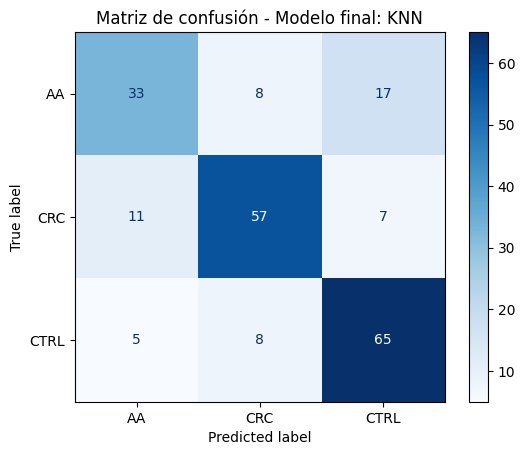

In [17]:
from sklearn.model_selection import cross_val_predict

y_pred_final = cross_val_predict(
    final_model,
    X,
    y,
    cv=cv
)

cm = confusion_matrix(y, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)

disp.plot(cmap='Blues')

plt.title(f'Matriz de confusión - Modelo final: {final_model_name}')

plt.show()

In [18]:
print(classification_report(y, y_pred_final))

              precision    recall  f1-score   support

          AA       0.67      0.57      0.62        58
         CRC       0.78      0.76      0.77        75
        CTRL       0.73      0.83      0.78        78

    accuracy                           0.73       211
   macro avg       0.73      0.72      0.72       211
weighted avg       0.73      0.73      0.73       211



### Interpretación de resultados

La matriz de confusión muestra que el modelo KNN presenta una capacidad adecuada para discriminar entre las tres categorías clínicas evaluadas (CTRL, AA y CRC). Las clases CRC y CTRL fueron las mejor identificadas, con recalls de 0.76 y 0.83, respectivamente, lo que indica que la mayoría de las muestras pertenecientes a estos grupos fueron clasificadas correctamente.

Por otro lado, la clase AA (adenoma avanzado) presentó el desempeño más bajo, con un recall de 0.57 y un F1-score de 0.62. En particular, se observa que 17 muestras AA fueron clasificadas como CTRL y 8 como CRC, evidenciando una mayor dificultad para distinguir esta clase respecto a las demás.

Este comportamiento es consistente con la progresión biológica del cáncer colorrectal, ya que los adenomas avanzados representan una etapa intermedia entre individuos sanos y pacientes con cáncer establecido. Por ello, es razonable que exista un mayor solapamiento entre los perfiles lipidómicos y metabolómicos de la clase AA y los otros grupos clínicos.

En términos generales, el modelo obtuvo un Accuracy de 0.73 y un F1 Macro de 0.72, mostrando una mejora sustancial respecto al baseline desarrollado en el Avance 3. Estos resultados sugieren que los biomarcadores seleccionados contienen información relevante para la clasificación multiclase y respaldan la viabilidad del enfoque propuesto para la detección y caracterización del cáncer colorrectal.

El modelo final fue seleccionado considerando no únicamente la métrica principal F1 Macro, sino también el balance entre desempeño predictivo, capacidad de generalización, complejidad computacional e interpretabilidad.

La comparación inicial permitió evaluar seis algoritmos de clasificación distintos bajo el mismo esquema de validación cruzada. Posteriormente, los dos modelos con mejor desempeño fueron sometidos a un proceso de ajuste fino de hiperparámetros con el objetivo de maximizar su capacidad predictiva y mejorar su generalización.

Dado el contexto biomédico del proyecto, la evaluación no se limitó al desempeño global. También se analizaron Accuracy, Precision Macro, Recall Macro, F1 Macro, matriz de confusión y reporte de clasificación, con especial atención a la capacidad de discriminación entre los grupos CTRL, AA y CRC.

Finalmente, se seleccionó el modelo que presentó el mejor equilibrio entre desempeño, robustez y capacidad de clasificación de las tres categorías clínicas, estableciendo así el modelo individual final para las siguientes etapas del proyecto.

## Conclusiones

En esta fase se construyeron y evaluaron múltiples modelos de clasificación para identificar la alternativa con mejor desempeño en la discriminación de los grupos clínicos CTRL, AA y CRC utilizando biomarcadores lipidómicos y metabolómicos.

La comparación inicial de modelos permitió identificar diferencias relevantes en capacidad predictiva entre los algoritmos evaluados. Posteriormente, se seleccionaron los dos modelos con mejor desempeño para realizar ajuste fino de hiperparámetros mediante búsqueda sistemática de configuraciones óptimas.

Los resultados mostraron que el ajuste de hiperparámetros mejoró el desempeño de ambos modelos seleccionados. En particular, K-Nearest Neighbors (KNN) incrementó su F1 Macro de 0.625 a 0.723, mientras que Decision Tree mejoró de 0.649 a 0.698.

Finalmente, KNN fue seleccionado como modelo individual final al obtener el mejor desempeño global en validación cruzada, alcanzando un Accuracy de 0.735, Precision Macro de 0.738, Recall Macro de 0.721 y F1 Macro de 0.723. Además de su desempeño superior, el modelo mostró una capacidad adecuada para discriminar entre las tres categorías clínicas evaluadas.

El análisis de la matriz de confusión evidenció que la clase AA continúa siendo la más difícil de clasificar, lo cual resulta consistente con su papel biológico como estado intermedio entre individuos control y pacientes con cáncer colorrectal.

En conjunto, los resultados obtenidos confirman que los biomarcadores seleccionados contienen información predictiva relevante para la clasificación multiclase del cáncer colorrectal. Asimismo, el modelo KNN constituye una base sólida para las siguientes etapas del proyecto, donde se evaluarán estrategias más avanzadas orientadas a maximizar el desempeño predictivo manteniendo la interpretabilidad de los resultados.

## Referencias

Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q): The ML Lifecycle Process*. INNOQ. https://ml-ops.org/content/crisp-ml

Kuhn, M., & Johnson, K. (2019). *Feature Engineering and Selection: A Practical Approach for Predictive Models*. Chapman and Hall/CRC.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning: With Applications in R* (2nd ed.). Springer.

Scikit-learn Developers. (2026). *Scikit-learn User Guide*. https://scikit-learn.org/stable/user_guide.html